# 5. Respiration & RSA (Principles: vagal brake, cardiorespiratory coupling)

1. PAPERS: [Sensing Systems for Respiration Monitoring:
A Technical Systematic Review](https://github.com/roeh-health/lamina/blob/general_wesad_analysis/papers/sensingSystemsForRespirationMonitoringTechnicalSystematicReview.pdf)

In [12]:
import os
import sys

import numpy as np
import pandas as pd
import neurokit2 as nk

notebook_dir = os.getcwd()

sys.path.append(os.path.join(notebook_dir, '../../signal'))

from data_processing import DataProcessing

In [2]:
respiration_frequency_sampling_rate = 25.0

## Load Data

In [3]:
data_path = "../../../data/WESAD/all_subjects/chest.csv"
df = DataProcessing.load_chest_df(base_dir=notebook_dir, file_type='.csv', path_to_file=data_path)
df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,S2,0
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.130950,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
60807595,0.9006,-0.0400,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
60807596,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.859740,0.233459,S17,0
60807597,0.9028,-0.0424,-0.1864,0.167130,-0.016068,7.262802,33.864290,0.318909,S17,0
60807598,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


## Get Specific Subject + Health Measure

In [4]:
## Option 1: Get s_id from .get_per_subject_dict()
s_id = 'S7'

per_subject_dfs, s_df = DataProcessing.get_data_per_subject(df, s_id)


### Option 2: Get s_id from per_subject_dfs
# s_df = per_subject_dfs[s_id]

### Option 3: Get s_id from per_subject_dfs
# s_id = 'None'

# per_subject_dfs = DataProcessing.get_per_subject_dict(df, s_id)
# print(per_subject_dfs)

# s3_id = 'S3'
# s3_df = DataProcessing.get_specific_subject_df(per_subject_dfs, s3_id)

In [5]:
s_df

,index,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,22626800,1.0696,-0.0140,1.4612,-0.019226,-0.048843,12.506866,33.993530,1.832581,S7,0
1,22626801,1.0654,-0.0102,1.4222,-0.016937,-0.007004,12.468719,33.932680,1.835632,S7,0
2,22626802,1.0654,0.0042,1.3202,-0.016159,0.071777,12.506866,33.970703,1.856995,S7,0
3,22626803,1.0666,0.0202,1.1464,-0.012405,0.088486,12.506485,34.008760,1.829529,S7,0
4,22626804,1.0602,0.0310,0.9192,-0.020325,0.090271,12.504959,33.887085,1.817322,S7,0
...,...,...,...,...,...,...,...,...,...,...,...
3666595,26293395,0.8586,-0.0958,-0.0390,0.156418,-0.036942,13.085556,34.917084,0.813293,S7,0
3666596,26293396,0.8526,-0.1026,-0.0430,0.115723,0.098831,13.089371,34.935608,0.816345,S7,0
3666597,26293397,0.8466,-0.1082,-0.0574,0.086380,0.199768,13.090134,34.943300,0.804138,S7,0
3666598,26293398,0.8422,-0.1138,-0.0814,0.139938,0.227646,13.081360,34.940247,0.834656,S7,0


In [7]:
health_measure = 'Resp'
resp_df = DataProcessing.get_specific_health_measure_df(s_df, health_measure)
resp_df

,Resp
0,1.832581
1,1.835632
2,1.856995
3,1.829529
4,1.817322
...,...
3666595,0.813293
3666596,0.816345
3666597,0.804138
3666598,0.834656


### Visualize Raw Data

<Axes: >

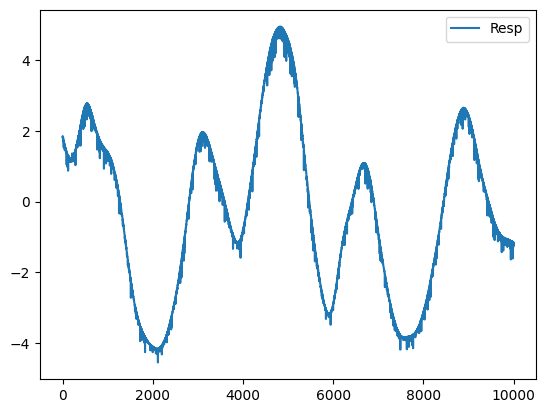

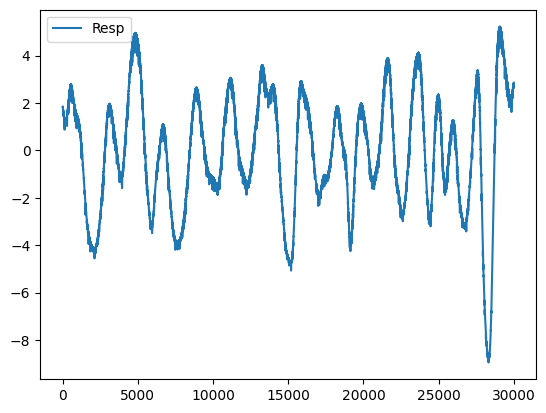

In [10]:
resp_df[:10000].plot.line()
resp_df[:30000].plot.line()

## Clean Data

In [ ]:
resp_df['Cleaned Resp'] = nk.rsp_clean(resp_df)
resp_df

,Resp,Cleaned Resp
0,1.832581,0.826737
1,1.835632,0.823691
2,1.856995,0.820619
3,1.829529,0.817520
4,1.817322,0.814394
...,...,...
3666595,0.813293,-0.001080
3666596,0.816345,-0.000927
3666597,0.804138,-0.000788
3666598,0.834656,-0.000663


### Visualize Cleaned Data

<Axes: >

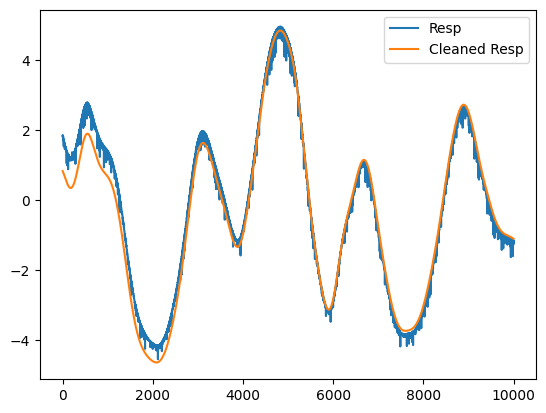

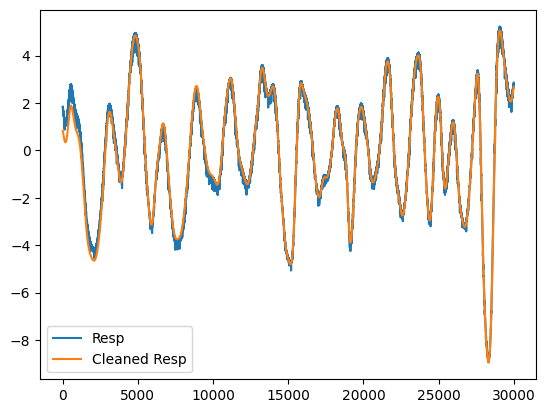

In [15]:
resp_df[:10000].plot.line()
resp_df[:30000].plot.line()